In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from scipy import signal

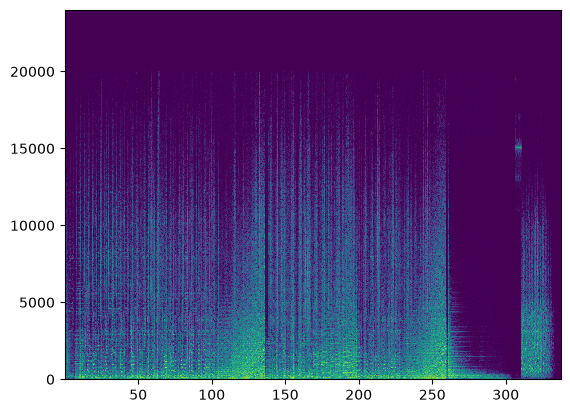

In [2]:
def song_spectrogram(path,window=4096):
    song,fs=librosa.load(path,sr=None)

    f,t,S=signal.spectrogram(song,fs,
    nperseg=window,
    noverlap=window//2,
    )
    return f,t,S

path="EE200 Project Song Database\\A Day In The Life.mp3"
f,t,S=song_spectrogram(path,4096)
S_db=20*np.log10(S+1e-10)

# print(t.shape,f.shape,S_db.shape)
plt.pcolormesh(t,f,S_db)
plt.show()

f shape = (2049,)
t shape = (7907,)
S_db shape = (2049, 7907)


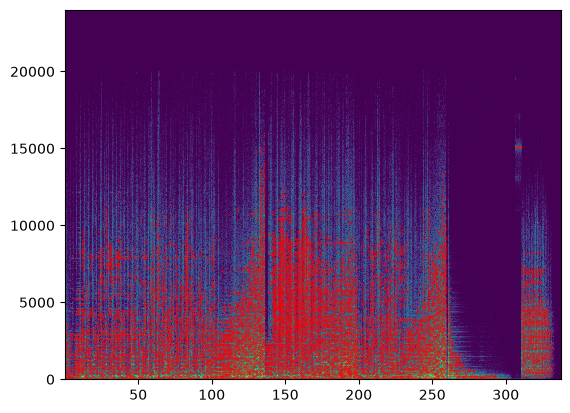

In [29]:
from scipy.ndimage import maximum_filter

def extract_peaks(f,t,S,percentile=95,size=15):
    S_db=10*np.log10(S+1e-10)
    local_max=S_db==maximum_filter(S_db,size=size)
    threshold=np.percentile(S_db,percentile)
    freq,time=np.where(local_max & (S_db>threshold))
    # print(f.shape,t.shape)
    # print(freq.shape,time.shape)
    freq_a=f[freq]
    time_a=t[time]
    return list(zip(time_a,freq_a))

peaks=extract_peaks(f,t,S,95,15)
peaks_arr=np.array(peaks)
print("f shape =", f.shape)
print("t shape =", t.shape)
print("S_db shape =", S_db.shape)
plt.pcolormesh(t,f,S_db,shading='auto')
plt.scatter(peaks_arr[:,0],peaks_arr[:,1],s=0.1,c='red')
plt.show()

In [30]:
def generate_hashes(peaks,tar_t=3,fan_value=10):
    peaks=sorted(peaks,key=lambda x:x[0])

    hashes=[]
    for i,anchor in enumerate(peaks):
        t1,f1=anchor
        for j in range(i+1,min(i+fan_value+1,len(peaks))):
            t2,f2=peaks[j]
            dt=t2-t1

            if dt>tar_t:
                break

            hash_key=(int(f1//10),int(f2//10),int(dt*100))
            hashes.append((hash_key,round(t1,2)))
    return hashes

In [31]:
database = {}
def add_song_to_database(song_name, hashes):
    for hash_key, t_anchor in hashes:
        if hash_key not in database:
            database[hash_key] = []
        database[hash_key].append((song_name, t_anchor))

In [32]:
import os

folder_path="EE200 Project Song Database"
count=0
for filename in os.listdir("EE200 Project Song Database"):
    path=os.path.join(folder_path,filename)
    song_name=os.path.splitext(filename)[0]
    try:
        f,t,S=song_spectrogram(path)
        peaks=extract_peaks(f,t,S)
        song_hashes=generate_hashes(peaks)
        add_song_to_database(song_name, song_hashes)
                
        print(f"Successfully indexed '{song_name}' ({len(song_hashes)} hashes stored).")
        count += 1
                
    except Exception as e:
        print(f"Failed to process {filename}. Error: {e}")
    print("-" * 40)

print(f"Total Songs:{count}")

Successfully indexed 'A Day In The Life' (132160 hashes stored).
----------------------------------------
Successfully indexed 'A Hard Day_s Night' (73435 hashes stored).
----------------------------------------
Successfully indexed 'Across The Universe' (94224 hashes stored).
----------------------------------------
Successfully indexed 'Back In The U.S.S.R.' (68475 hashes stored).
----------------------------------------
Successfully indexed 'Blackbird' (48145 hashes stored).
----------------------------------------
Successfully indexed 'Bohemian Rhapsody' (88595 hashes stored).
----------------------------------------
Successfully indexed 'Can_t Buy Me Love' (59795 hashes stored).
----------------------------------------
Successfully indexed 'Crazy Little Thing Called Love' (87815 hashes stored).
----------------------------------------
Successfully indexed 'Day Tripper' (90785 hashes stored).
----------------------------------------
Successfully indexed 'Don_t Stop Me Now' (105381 

In [33]:
import pickle
import os

os.makedirs("database", exist_ok=True)

with open("database/hash_database.pkl", "wb") as f:
    pickle.dump(database, f)

print("Database saved successfully!")

Database saved successfully!


In [34]:
def generate_noisy_query(path,noise_std=0.02,start_time=0,clip_dur=8):
    song,fs=librosa.load(path, sr=None)
    clip_len=int(clip_dur*fs)
    start=int(start_time*fs)

    clip=song[start:start+clip_len]
    noise=np.random.normal(0,noise_std,len(clip))
    noisy_clip=clip+noise
    noisy_clip/=np.max(np.abs(noisy_clip))

    return noisy_clip, fs

query,fs=generate_noisy_query(
    "EE200 Project Song Database/A Day In The Life.mp3",
    start_time=1.4)

In [35]:
def spectrogram_from_audio(audio, fs, window=4096):
    f, t, S = signal.spectrogram(
        audio,fs,
        nperseg=window,noverlap=window//2)
    return f, t, S

f,t,q=spectrogram_from_audio(query,fs)
peaks=extract_peaks(f,t,q)
print("Peaks ",len(peaks))
q_hashes=generate_hashes(peaks)
print("Queries ",len(q_hashes))

Peaks  1541
Queries  15355


In [36]:
from collections import defaultdict

def identify_song(q_hashes,database,n=3):
    votes=defaultdict(int)
    for hash_key,q_time in q_hashes:
        if hash_key not in database:
            continue
        for song_name,time_db in database[hash_key]:
            offset=round(time_db-q_time, 1)
            votes[(song_name, offset)] += 1

    if len(votes)==0:
        return None

    top = sorted(votes.items(), key=lambda x: x[1], reverse=True)[:10]

    print("Top matches:")
    cnt=0
    for (song, offset), score in top:
        print(f"{song:35s} offset={offset/10:5.1f}s  votes={score}")
        cnt+=1
        if cnt>=n:
            break
    return top[0]

result=identify_song(q_hashes,database)
print(result)

Top matches:
A Day In The Life                   offset=  0.1s  votes=120
A Day In The Life                   offset=  0.6s  votes=11
A Day In The Life                   offset=  0.3s  votes=10
(('A Day In The Life', np.float64(1.4)), 120)


In [37]:
noise_levels = [0, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]

path="EE200 Project Song Database/A Day In The Life.mp3"
for sigma in noise_levels:
    query, fs = generate_noisy_query(path,sigma)
    f,t,S = spectrogram_from_audio(query, fs)
    peaks = extract_peaks(f, t, S)
    hashes = generate_hashes(peaks)

    result = identify_song(hashes, database)
    print(f"σ={sigma:.2f} -> {result}")

Top matches:
A Day In The Life                   offset=  0.0s  votes=854
A Day In The Life                   offset=  3.0s  votes=19
A Day In The Life                   offset= 22.5s  votes=17
σ=0.00 -> (('A Day In The Life', np.float64(0.0)), 854)
Top matches:
A Day In The Life                   offset=  0.0s  votes=599
A Day In The Life                   offset=  0.1s  votes=15
A Day In The Life                   offset=  3.0s  votes=15
σ=0.01 -> (('A Day In The Life', np.float64(0.0)), 599)
Top matches:
A Day In The Life                   offset=  0.0s  votes=172
A Day In The Life                   offset= 22.5s  votes=16
A Day In The Life                   offset=  0.3s  votes=11
σ=0.02 -> (('A Day In The Life', np.float64(0.0)), 172)
Top matches:
A Day In The Life                   offset=  0.0s  votes=54
A Day In The Life                   offset=  0.1s  votes=8
A Day In The Life                   offset= 22.5s  votes=7
σ=0.05 -> (('A Day In The Life', np.float64(0.0)), 54)
Top 